In [1]:
import sys
sys.path.append('..')
import module
import pandas as pd

In [2]:
R = module.Rack(inventory_file = "salamander_inventory.csv", filename = "current.csv", euthanasia_log_file = "euthanasia_log.csv")

Loaded existing inventory from salamander_inventory.csv
State is saving to current.csv


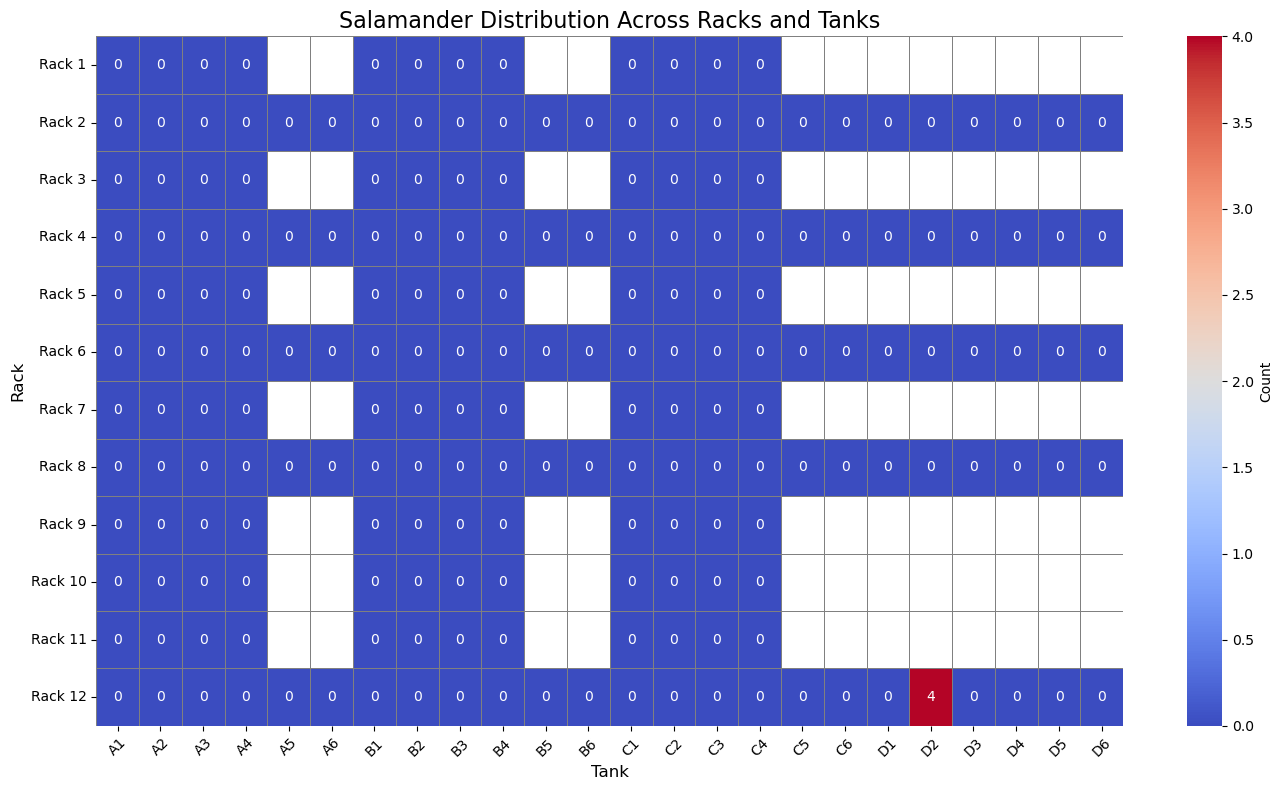

In [3]:
R.plot_rack_space()

In [4]:
R.inventory

,Animal ID,Tank,Rack,DOB,Environmental Condition,Sex,Lineage,Transgenic Line,Experimental Holds,Species,Protocol Number,Experimental History
0,SAL_001,B5,Rack 1,2021-09-05,Aquatic,NaN,Sweden,hsyn-GFP,False,Polypterus senegalus,AABL,EdU
1,SAL_002,A6,Rack 5,2024-02-03,Terrestrial,NaN,YxO,GCamP6s,False,Polypterus senegalus,AABY,EdU
2,SAL_003,B5,Rack 1,2022-02-09,Terrestrial,NaN,Sweden,Wildtype,True,Polypterus senegalus,AABI,Behavior Conditioning
3,SAL_005,A6,Rack 5,2024-06-21,Aquatic,Male,YxO,GCamP6s,True,Ambystoma mexicanum,AABL,Behavioral Study
4,SAL_006,B5,Rack 1,2022-01-16,Reaqua,NaN,Sweden,Wildtype,False,Pleurodeles waltl,AABL,Behavior Conditioning
5,SAL_007,D2,Rack 12,2024-01-22,Reaqua,NaN,Jungle Bobs,Wildtype,True,Polypterus senegalus,AABL,Regeneration
6,SAL_008,D2,Rack 12,2020-07-19,Reaqua,NaN,Jungle Bobs,hsyn-GFP,True,Ambystoma mexicanum,AABI,Viral injection
7,SAL_009,D2,Rack 12,2024-02-02,Reaqua,NaN,Sweden,hsyn-GFP,True,Polypterus senegalus,AABI,Viral injection
8,SAL_010,D2,Rack 12,2023-06-12,Aquatic,NaN,Jungle Bobs,GCamP6s,True,Polypterus senegalus,AABF,Behavior Conditioning
9,SAL_012,A5,Rack 3,2022-05-22,Aqua,NaN,PxO,GCaMP,,Pleurodeles waltl,AABL1550,NaN


In [4]:
R.add_salamanders(1, '2022-05-22', "Pleurodeles waltl", "hsyn-GCamP6s", "PxO", "AABL1550", "Rack 3", "A5", "Aqua", "Female", " ", "Edu")

1 new salamander(s) adding successfully.
Inventory saved to salamander_inventory.csv.
State is saving to current.csv
1 baby salamanders added to Rack 3, tank A5, with DOB 2022-05-22.


In [5]:
R.euthanize_animal('SAL_018','2025-4-12', 9, "Male", "Histology", "AOG", complications="found dead")

Log successful
Inventory saved to salamander_inventory.csv.
State is saving to current.csv
Animal SAL_018 euthanized and removed from inventory.


In [4]:
R.euthanasia_log

[{'Animal ID': 'SAL_016',
  'Tank': 'A5',
  'Rack': 'Rack 3',
  'DOB': '2022-05-22',
  'Environmental Condition': 'Aqua',
  'Lineage': 'PxO',
  'Transgenic Line': 'hsyn-GCamP6s',
  'Experimental Holds': ' ',
  'Species': 'Pleurodeles waltl',
  'Protocol Number': 'AABL1550',
  'Experimental History': 'Edu',
  'DOD': '2025-4-12',
  'Weight (g)': 9,
  'Sex': 'Male',
  'Purpose': 'Histology',
  'Experimenter': 'AOG',
  'Complications': 'found dead'},
 {'Animal ID': 'SAL_013',
  'Tank': 'A5',
  'Rack': 'Rack 3',
  'DOB': '2022-05-22',
  'Environmental Condition': 'Aqua',
  'Lineage': 'PxO',
  'Transgenic Line': 'GCaMP',
  'Experimental Holds': ' ',
  'Species': 'Pleurodeles waltl',
  'Protocol Number': 'AABL1550',
  'Experimental History': nan,
  'DOD': '2025-4-12',
  'Weight (g)': 9,
  'Sex': 'Male',
  'Purpose': 'Histology',
  'Experimenter': 'AOG',
  'Complications': 'found dead'}]

In [22]:
R.save_inventory()

Inventory saved to salamander_inventory.csv.


In [7]:
R.save_state()

State is saving to current.csv


In [8]:
R.undo()

Undo successful: reverted inventory and euthanasia log.
Log successful


In [5]:
R.move_salamander(["SAL_007", "SAL_008", "SAL_010"], "Rack 12", "D2")
#allows tanks/racks that dont exist

Animal SAL_007 moved to Rack 12.
D2
Log successful
Animal SAL_008 moved to Rack 12.
D2
Log successful
Animal SAL_010 moved to Rack 12.
D2
Log successful
Inventory saved to salamander_inventory.csv.
State is saving to current.csv


In [4]:
R.is_valid_tank("Rack 13", "D2")

True

In [10]:
R.edit_salamander_info(
    "SAL_005",
    **{
        "Environmental Condition": "Aquatic",  # Correct usage
        "Sex": "Male",
        "Protocol Number": "AABL",
        "Experimental History": "Behavioral Study"
    }
)

Inventory saved to salamander_inventory.csv.
State is saving to current.csv
Log successful
Updated SAL_005:
 - Environmental Condition: Terrestrial → Aquatic
 - Sex: Female → Male
 - Protocol Number: AABL → AABL
 - Experimental History: Viral injection → Behavioral Study


In [7]:
print(R.inventory.columns.tolist())


['Animal ID', 'Tank', 'Rack', 'DOB', 'Environmental Condition', 'Sex', 'Lineage', 'Transgenic Line', 'Experimental Holds', 'Species', 'Protocol Number', 'Experimental History']


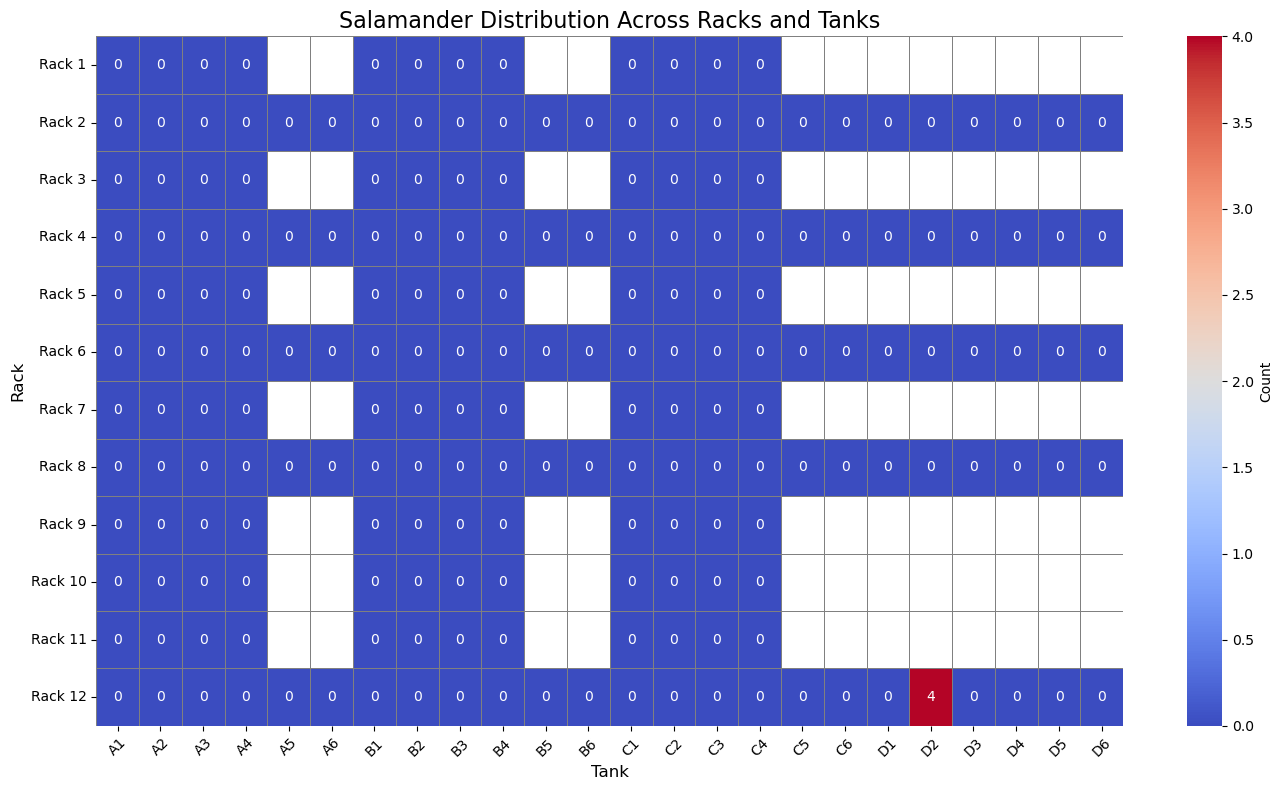

In [4]:
R.plot_rack_space()
#Build on this more - zooming in on one rack or one tank
#Maybe tie into search function

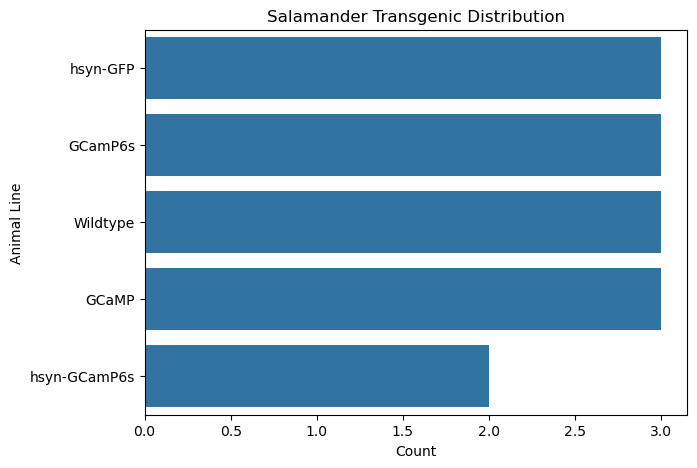

In [21]:
R.plot_transgenic_distribution()

In [ ]:
#add larval euthanasia log? 

In [17]:
R.search_salamanders(Rack = "Rack 13")
#Cant find by column names if there is a space/multiple words
#returns females as partial match to male
#Add a summary of number of animals?

'No matches found.'

In [19]:
criteria = {
    "Environmental Condition": "Aquatic",
    "Protocol Number": "AABL"
}
R.search_salamanders(**criteria)
#Options for fixing issue - if adding _ to colnames need to update in module where nececssary
#self.inventory.columns = [col.replace(" ", "_") for col in self.inventory.columns]

,Animal ID,Tank,Rack,DOB,Environmental Condition,Sex,Lineage,Transgenic Line,Experimental Holds,Species,Protocol Number,Experimental History
0,SAL_001,B5,Rack 1,2021-09-05,Aquatic,NaN,Sweden,hsyn-GFP,False,Polypterus senegalus,AABL,EdU
3,SAL_005,A6,Rack 5,2024-06-21,Aquatic,Male,YxO,GCamP6s,True,Ambystoma mexicanum,AABL,Behavioral Study


In [12]:
R.analyze_euthanasia_log()
#add by experimenter 

,Protocol Number,Year,total_euthanized,complications
0,AABL1550,2025,2,2


In [15]:
"""To do: 
-choose option for search function
-add more plotting features?
-update readme
-start testing with streamlit
"""

'To add: '

In [20]:
summary = R.analyze_euthanasia_log()
print(summary)

  Protocol Number  Year  total_euthanized  complications
0        AABL1550  2025                 2              2
